In [2]:
from pathlib import Path
import sys

_cwd = Path.cwd()
_code_dir = _cwd / 'code' if (_cwd / 'code' / 'ecg').is_dir() else _cwd
sys.path.insert(0, str(_code_dir.resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from ecg import RECORDS_FOLDER, get_available_patients, load_patient_table, read_subject_data
from ecg.features import split_annotations_by_type


## Distribuições

Exploração demográfica e de anotações do MIT-BIH Arrhythmia Database.


In [3]:
df = load_patient_table(RECORDS_FOLDER)
available_patients = get_available_patients(RECORDS_FOLDER)
subject_id = available_patients[2]
signal, fs, annotation = read_subject_data(subject_id)
df.head()


,ID,Idade,Gênero,Medicamentos
0,100,69,M,"Aldomet, Inderal"
1,101,75,F,Diapres
2,102,84,F,Digoxin
3,103,-1,M,"Diapres, Xyloprim"
4,104,66,F,"Digoxin, Pronestyl"


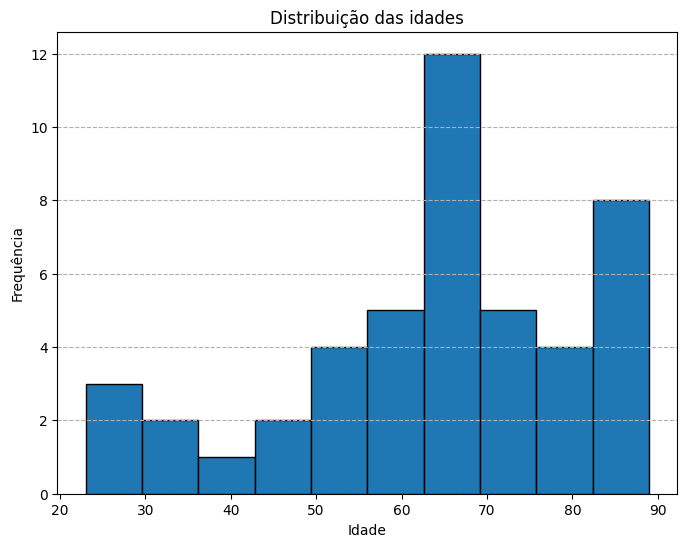

In [4]:
valid_ages = df['Idade'][df['Idade'] != -1]

plt.figure(figsize=(8, 6))
plt.hist(valid_ages, edgecolor='black')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Distribuição das idades')
plt.grid(linestyle='--', axis='y')
plt.show()

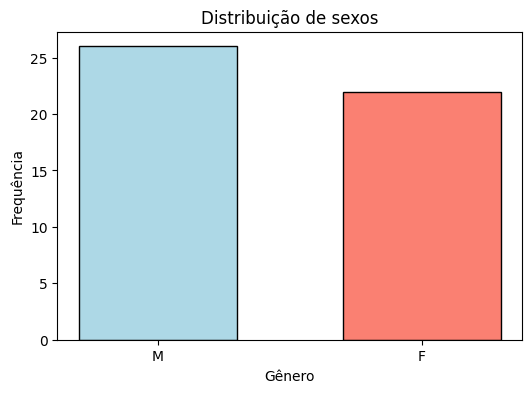

In [5]:
gender_count = df['Gênero'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    gender_count.index,
    gender_count.values,
    edgecolor='black',
    color=['lightblue', 'salmon'],
    width=0.6,
)
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.title('Distribuição de sexos')
plt.show()

2188 4


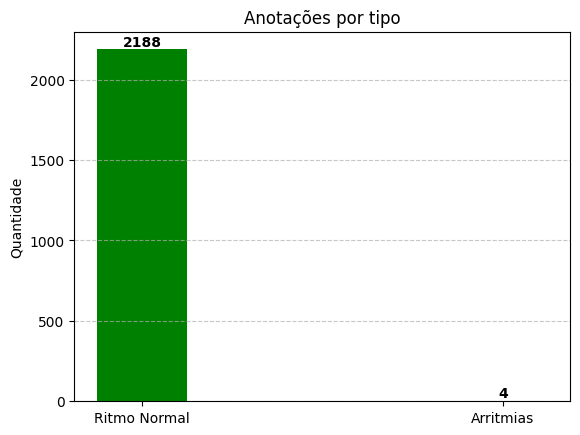

In [6]:
normal_times, arrhythmia_times = split_annotations_by_type(annotation, fs)
normal_count = len(normal_times)
arrythm_count = len(arrhythmia_times)
print(normal_count, arrythm_count)

labels = ['Ritmo Normal', 'Arritmias']
values = [normal_count, arrythm_count]
bars = plt.bar(labels, values, color=['green', 'red'], width=0.25)
plt.ylabel('Quantidade')
plt.title('Anotações por tipo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()

In [7]:
normal_count / (normal_count + arrythm_count) * 100

99.81751824817519